# London Airbnb Saturday: Model Training & Comparison

Continues from `pipeline.ipynb`. Notebooks don't share kernel state across
files, so the cells below rebuild `X_train_transformed` / `y_train` by re-running the
exact cleaning, feature engineering, and preprocessing steps from that notebook. Nothing
new here, just reproducing Friday's pipeline output so this notebook is runnable on its
own. See `pipeline.ipynb` for the reasoning behind each step.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [2]:
# Update this path to wherever you saved the download.
# pandas reads .csv.gz directly - no need to unzip first.
DATA_PATH = "../data/listings.csv.gz"

df = pd.read_csv(DATA_PATH, low_memory=False)
df.shape


(92638, 90)

In [3]:
df["price_clean"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price_clean"].describe()


count     62240.000000
mean        271.469220
std        2190.599006
min           2.230000
25%         100.000000
50%         180.000000
75%         300.032500
max      527524.000000
Name: price_clean, dtype: float64

In [4]:
import ast

def parse_amenities(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError, TypeError):
        return []

df["amenities_list"] = df["amenities"].apply(parse_amenities)
df["amenities_count"] = df["amenities_list"].apply(len)
df["amenities_count"].describe()


count    92638.000000
mean        28.777424
std         15.326513
min          0.000000
25%         15.000000
50%         29.000000
75%         40.000000
max        103.000000
Name: amenities_count, dtype: float64

In [5]:
df["log_price"] = np.log1p(df["price_clean"])

In [6]:
KEY_AMENITIES = ["Wifi", "Kitchen", "Free parking", "Air conditioning", "Washer", "Heating"]

for amenity in KEY_AMENITIES:
    col_name = "has_" + amenity.lower().replace(" ", "_")
    df[col_name] = df["amenities_list"].apply(lambda lst: int(amenity in lst))

flag_cols = [f"has_{a.lower().replace(' ', '_')}" for a in KEY_AMENITIES]
df[flag_cols + ["log_price"]].corr()["log_price"]


has_wifi                0.029859
has_kitchen             0.172993
has_free_parking             NaN
has_air_conditioning    0.236376
has_washer              0.121011
has_heating             0.093973
log_price               1.000000
Name: log_price, dtype: float64

In [7]:
df["beds_per_accommodate"] = df["beds"] / df["accommodates"].replace(0, np.nan)
df["bath_per_bedroom"] = df["bathrooms"] / df["bedrooms"].replace(0, np.nan)

df[["beds_per_accommodate", "bath_per_bedroom", "log_price"]].corr()["log_price"]


beds_per_accommodate   -0.223235
bath_per_bedroom       -0.217020
log_price               1.000000
Name: log_price, dtype: float64

In [8]:
df["is_fully_blocked"] = (df["availability_365"] == 0).astype(int)
df["is_fully_blocked"].value_counts()


is_fully_blocked
0    66117
1    26521
Name: count, dtype: int64

In [9]:
# Set from the quantiles above: the 99th percentile is a reasonable starting point,
# adjust if the jump to the true max happens earlier or later than expected
PRICE_CAP = df["price_clean"].quantile(0.99)

df["price_capped"] = df["price_clean"].clip(upper=PRICE_CAP)
df["log_price_capped"] = np.log1p(df["price_capped"])

df["price_capped"].describe()


count    62240.000000
mean       244.360527
std        225.066039
min          2.230000
25%        100.000000
50%        180.000000
75%        300.032500
max       1373.457500
Name: price_capped, dtype: float64

In [10]:
model_df = df.dropna(subset=["price_clean"]).copy()
model_df.shape


(62240, 105)

In [11]:
NUMERIC_FEATURES = [
    "accommodates", "bathrooms", "beds_per_accommodate", "bath_per_bedroom",
    "amenities_count", "host_listings_count", "hosts_time_as_host_years",
    "review_scores_location",
]

BINARY_FEATURES = [
    "is_fully_blocked", "has_kitchen", "has_air_conditioning", "has_washer", "has_heating",
]

CATEGORICAL_FEATURES = ["room_type", "neighbourhood_cleansed"]

TARGET = "log_price_capped"


In [12]:
X = model_df[NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES]
y = model_df[TARGET]

X.shape, y.shape, y.isna().sum()


((62240, 15), (62240,), np.int64(0))

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((49792, 15), (12448, 15))

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

binary_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # sparse_output is sklearn 1.2+; use sparse=False on older versions
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("binary", binary_pipeline, BINARY_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
])


In [15]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_transformed.shape


(49792, 50)

## Saturday: Model Training & Comparison

### 1. Imports + reproducibility constant

In [16]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42

### 2. CV strategy: StratifiedKFold on qcut-binned price

In [17]:
price_bins = pd.qcut(y_train, q=10, labels=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_splits = list(skf.split(X_train_transformed, price_bins))

### 3. Scoring (log-RMSE + R2)

y_train is already log_price_capped, so no make_scorer/log1p conversion is needed here.

In [18]:
scoring = ["neg_root_mean_squared_error", "r2"]

### 4. LinearRegression baseline

In [19]:
lr_results = cross_validate(
    LinearRegression(),
    X_train_transformed, y_train,
    cv=cv_splits,
    scoring=scoring,
)

### 5. Ridge

In [20]:
ridge_results = cross_validate(
    Ridge(alpha=1.0, random_state=RANDOM_STATE),
    X_train_transformed, y_train,
    cv=cv_splits, scoring=scoring,
)

### 6. Lasso

No prior vault lesson on Lasso, so watch for convergence warnings (raise max_iter).

In [21]:
lasso_results = cross_validate(
    Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=10000),
    X_train_transformed, y_train,
    cv=cv_splits, scoring=scoring,
)

### 7. RandomForestRegressor

In [22]:
rf_results = cross_validate(
    RandomForestRegressor(random_state=RANDOM_STATE),
    X_train_transformed, y_train,
    cv=cv_splits, scoring=scoring,
)

### 8. Results comparison table

Report mean *and* std of RMSE/R2 per model. Std is what decided the final model on Ames.

In [23]:
results = {
    "LinearRegression": lr_results,
    "Ridge": ridge_results,
    "Lasso": lasso_results,
    "RandomForest": rf_results,
}

summary = pd.DataFrame({
    name: {
        "rmse_mean": -res["test_neg_root_mean_squared_error"].mean(),
        "rmse_std": res["test_neg_root_mean_squared_error"].std(),
        "r2_mean": res["test_r2"].mean(),
        "r2_std": res["test_r2"].std(),
    }
    for name, res in results.items()
}).T

summary

,rmse_mean,rmse_std,r2_mean,r2_std
LinearRegression,0.465440,0.005693,0.649722,0.007302
Ridge,0.465440,0.005689,0.649722,0.007295
Lasso,0.786457,0.002652,-0.000003,0.000002
RandomForest,0.433367,0.006089,0.696317,0.007609


## Tune Best Model + Conclusions


RandomForest won Saturday's comparison clearly — RMSE 0.4334 vs. 0.4654 for both linear
models, R² 0.6963 vs. 0.6497 — enough of a margin to justify tuning it rather than the
runner-up.

### Test set — transform, don't fit

In [24]:
X_test_transformed = preprocessor.transform(X_test)
X_test_transformed.shape

(12448, 50)

### RandomizedSearchCV on RandomForestRegressor

In [25]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv_splits,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_search.fit(X_train_transformed, y_train)
random_search.best_params_, random_search.best_score_

({'n_estimators': 500,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 'log2',
  'max_depth': None},
 np.float64(-0.42187689461885886))

### Evaluate the tuned model on the held-out test set

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test_transformed)

test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

test_rmse, test_r2

(0.4103500789594809, 0.724456446336168)

### Actual vs. predicted

Text(0.5, 1.0, 'Actual vs Predicted Prices - Tuned Random Forest (test set)')

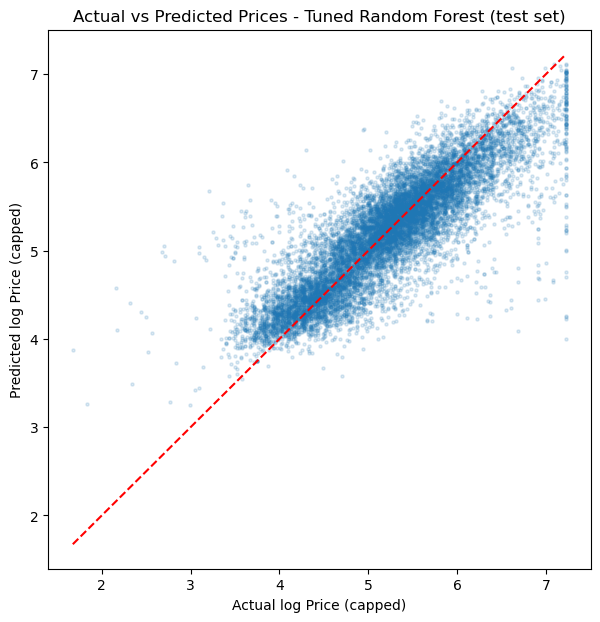

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, s=5, alpha=0.15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual log Price (capped)")
plt.ylabel("Predicted log Price (capped)")
plt.title("Actual vs Predicted Prices - Tuned Random Forest (test set)")

### Residual distribution

Text(0.5, 1.0, 'Distribution of Residuals - Tuned Random Forest (test set)')

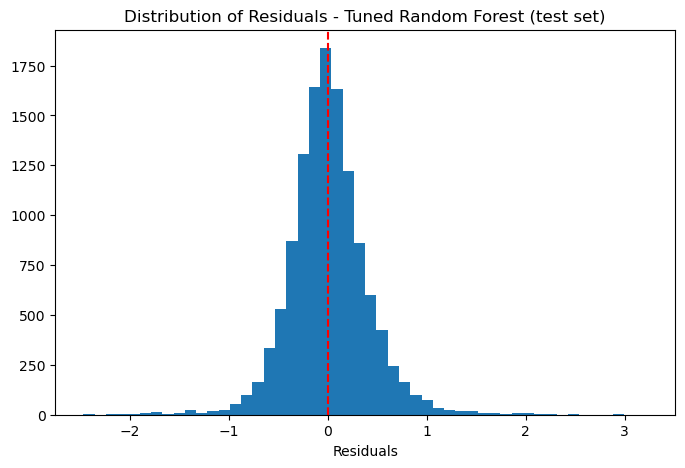

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuals")
plt.title("Distribution of Residuals - Tuned Random Forest (test set)")

### Observations

Tuning improved CV RMSE from 0.4334 (untuned RF) to 0.4219, about a 2.7% drop. Test RMSE (0.4104) came in even better than the search's own CV score, so there's no sign of overfitting to the search itself.

best_params_ picked the most flexible option on every axis: n_estimators=500 (top of the grid), max_depth=None, min_samples_split=2, min_samples_leaf=1. Since n_estimators hit the ceiling of what was searched, 500 isn't necessarily optimal, more trees might do better and the grid should probably go higher next time. max_features='log2' won over sqrt and None, which decorrelates trees a bit more than sklearn's usual default.

The actual vs. predicted scatter mostly sits close to the diagonal, but there's a vertical band of points around actual = 7.2. That's log1p of the price cap. Every listing clipped at the 99th percentile ends up with the same target value, so the model's predictions for that group spread from about 4 to 7.2. That's the capping decision showing up in the plot, not a problem with the model.

The residual histogram peaks sharply at 0 and is fairly symmetric, with a slightly longer tail on the positive side (a few residuals reaching +3 vs about -2.5 on the negative side). The model occasionally underpredicts a listing by a lot, a bit more often than it overpredicts by the same amount.



### Conclusions

### Conclusions

Tuning the RandomForest gave a real, if modest, improvement over the untuned version: test RMSE 0.4104 vs. CV RMSE 0.4334, R² 0.7245 vs. 0.6963. That confirms RandomForest as the right model here over the linear baselines (RMSE around 0.465) and Lasso, which collapsed to R² near 0. The hyperparameter grid was probably a bit too narrow on the complexity side. n_estimators landing at the top of its range suggests trying 800-1000 trees next time might push RMSE down further.

All the error numbers here are in log price space, not pounds. Converting to an interpretable £ error would need an np.expm1() pass before showing this to anyone non-technical. The 99th percentile price cap also means this model was never trained to tell the top 1% of London listings apart by price, which is exactly why that vertical band shows up in the scatter plot. That's a limitation of scope, not a bug.
